In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [2]:
#job array setup
num_jobs=30 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
if job_id==0: job_id=1

num_parcels=len(parcel['xh']) #total num of variables
job_range = num_parcels//num_jobs #number of parcels per job 
start_job = (job_id - 1) * job_range
end_job = start_job + job_range
if job_id==num_jobs: end_job=num_parcels-1

parcel=parcel.isel(xh=slice(start_job,end_job))

In [2]:
# Loading Important Variables
##############
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    print('done')
    empty_like=True

loading neccessary variables
done


In [5]:
#Eulerian Cloudy Updrafts
##############
w_thresh=0.5
qcqithresh=1e-9
D=np.zeros_like(w_data) 
where1=np.where((w_data>=w_thresh)&(qc_plus_qi>=qcqithresh))
where1

(array([  6,   6,   6, ..., 140, 140, 140]),
 array([ 7,  7,  7, ..., 31, 31, 31]),
 array([45, 46, 48, ..., 64, 99, 99]),
 array([260, 260, 260, ..., 442, 420, 421]))

In [6]:
#Lagrangian Position Arrays
##############
def grid_location(x,y,z): #faster
    #finding xf and yf
    ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
    xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
    dy=np.round(dy);dx=np.round(dx)

    #digitizing
    zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
    if which_zh.ndim==0:
        which_zh=np.array([which_zh])
    which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
    which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

    #fixing boundaries
    which_zh[np.where(which_zh==len(data['zh']))]-=1
    which_yh[np.where(which_yh==len(data['yh']))]-=1
    which_xh[np.where(which_xh==len(data['xh']))]-=1
    return which_zh,which_yh,which_xh
x=parcel['x'].data;y=parcel['y'].data;z=parcel['z'].data
Z,Y,X=grid_location(x,y,z)

In [ ]:
#Calculating Lagrangian Binary Array 
############################

A=np.zeros_like(Z)

# max_count= 1 #TESTING
max_count = len(parcel['xh'])

start_time = time.time()    
for count,p in enumerate(np.arange(A.shape[1])):
    condz=Z[where1[0],p]==where1[1]
    condy=Y[where1[0],p]==where1[2]
    condx=X[where1[0],p]==where1[3]
    where2=np.where(condz&condy&condx)

    #find (t,p) to index
    t_inds=where1[0][where2]
    p_ind=p

    #indexing T(t,p)
    A[t_inds,p]=1

    if np.mod(count,1000)==0: print(f'p={p}/{A.shape[1]}\n')
    if count==max_count: break #TESTING

end_time = time.time()
print(f"Time taken: {end_time - start_time:.6f} seconds")
# secs_per_p=(end_time-start_time)/max_count #seconds per parcel
# tot_secs=secs_per_p*len(parcel['xh']) #seconds for 1.25e5 parcels
# tot_mins=tot_secs/60**2
# tot_mins #19 mins calculated from 566 parcels

# Saving Data
##############
import h5py
with h5py.File(dir+f'lagrangian_binary_threshold_job{job_id}.h5', 'w') as f:
    # Save the array as a variable in the file
    f.create_dataset('A', data=A) #binary array
    f.create_dataset('Z', data=Z)
    f.create_dataset('Y', data=Y)
    f.create_dataset('X', data=X)

In [6]:
# READING BACK DATA LATER
# All job arrays are added back together

##############
num_jobs=30

import h5py
job_id=1
with h5py.File(dir+f'lagrangian_binary_threshold_job{job_id}.h5', 'r') as f:
    # Load the dataset by its name
    A = f['A'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

for job_id in np.arange(2,num_jobs+1):
    with h5py.File(dir+f'lagrangian_binary_threshold_job{job_id}.h5', 'r') as f:
        A_append = f['A'][:]
        Z_append = f['Z'][:]
        Y_append = f['Y'][:]
        X_append = f['X'][:]

        
        A=np.hstack((A, A_append))
        Z=np.hstack((Z, Z_append))
        Y=np.hstack((Y, Y_append))
        X=np.hstack((X, X_append))

import h5py
with h5py.File(dir+f'lagrangian_binary_array.h5', 'w') as f:
    # Save the array as a variable in the file
    f.create_dataset('A', data=A) #binary array
    f.create_dataset('Z', data=Z)
    f.create_dataset('Y', data=Y)
    f.create_dataset('X', data=X)

In [110]:
# #CHECKING THAT THRESHOLDS WORKED IN A
# w_data=data['w'].interp(zf=data['zh']).data
# t=30
# where=np.where(A[t]==1)
# hey=w_data[t,Z[t,where],Y[t,where],X[t,where]]
# print(f'min w is {hey.min()}')

# qc_plus_qi=data['qc']+data['qi']
# hey=qc_plus_qi[t,Z[t,where],Y[t,where],X[t,where]]
# print(f'min qcqi is {hey.min()}')

min w is 0.5006372332572937
min qcqi is 1.0031879771332797e-09


In [ ]:
#ENTRAINMENT/DETRAINMENT

In [82]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [8]:
# Reading Back Data Later
##############
import h5py
with h5py.File(dir+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A = f['A'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [57]:
def ed(z,t,type):
    #Get Z Locations
    zs=Z[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    z_ind=np.where(zs==z)
    A_z=D[z_ind]
    
    #Esentially the H function

    if type=='e':
        A_z[A_z<0]=0 #entrainment
    if type=='d':
        A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    if type=='d': 
        A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    constant=(m_out/Lx/Ly/dz/dt) 
    # constant=1
    A_sum*=constant
    return A_sum

#creates 2d storage array
tlen=len(data['time'])
zlen=len(data['zh'])
profile_array_e=np.zeros((tlen,zlen))
profile_array_d=np.zeros((tlen,zlen))

#Adding to Profile Array
import itertools
ts = range(0, 141)  # ts from 0 to 140
zs = range(0, 34)   # zs from 0 to 34
for count, (t, z) in enumerate(itertools.product(ts, zs)):
    # if np.mod(count,10000)==0: print(f'{count*100/len(ts):.2f}%')
    A_sum=ed(z,t,type='e')
    profile_array_e[t,z]+=A_sum

    A_sum=ed(z,t,type='d')
    profile_array_d[t,z]+=A_sum

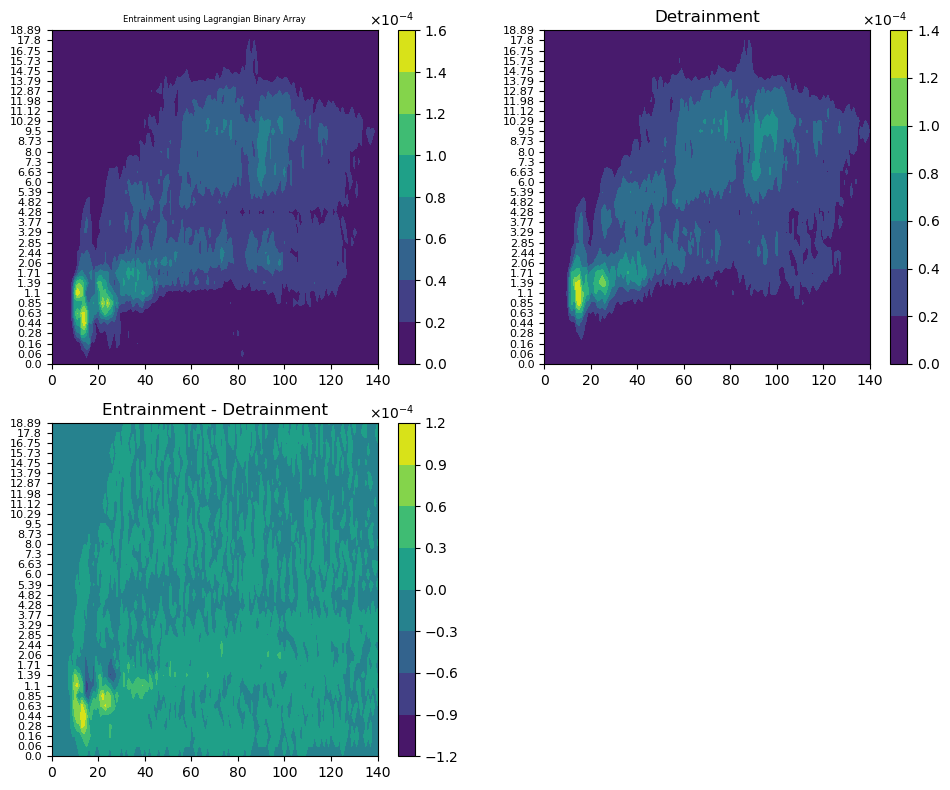

In [87]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

# First subplot: Entrainment
ax1 = fig.add_subplot(gs[0, 0])
contour1 = ax1.contourf(profile_array_e.T)
cbar1=fig.colorbar(contour1, ax=ax1)
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=6)

# Second subplot: Detainment
ax2 = fig.add_subplot(gs[0, 1])
contour2 = ax2.contourf(profile_array_d.T)
cbar2 = fig.colorbar(contour2, ax=ax2)
ax2.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax2.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax2.set_title('Detrainment')

# Second subplot: Detainment
ax3 = fig.add_subplot(gs[1, 0])
contour3 = ax3.contourf((profile_array_e-profile_array_d).T)
cbar3=fig.colorbar(contour3, ax=ax3)
ax3.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax3.set_title('Entrainment - Detrainment')

# Display the plot
plt.tight_layout()




from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
for cbar in (cbar1,cbar2, cbar3):  # These must be Colorbar instances
    cbar.formatter = formatter
    cbar.update_ticks()

Text(0.5, 1.0, 'entrainment and detrainment using lagrangian binary array')

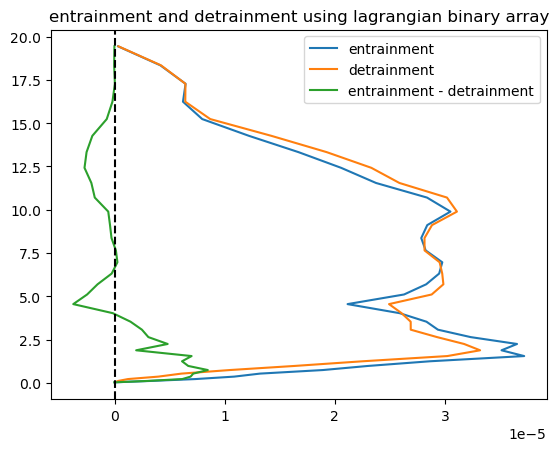

In [71]:
plt.plot(np.mean(profile_array_e,axis=(0)),data['zh'],label='entrainment')
plt.plot(np.mean(profile_array_d,axis=(0)),data['zh'],label='detrainment')
plt.plot(np.mean(profile_array_e-profile_array_d,axis=0),data['zh'],label='entrainment - detrainment')
plt.axvline(0,color='k',linestyle='dashed')

plt.legend(); plt.title('entrainment and detrainment using lagrangian binary array')

In [ ]:
############## TESTING 3D

In [115]:
def ed3d(t,z,y,x,type):
    #Get Z Locations
    zs=Z[t,:]
    ys=Y[t,:]
    xs=X[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    zyx_ind=np.where((zs==z)&(ys==y)&(xs==x))
    A_z=D[zyx_ind]
    
    #Esentially the H function

    if type=='e':
        A_z[A_z<0]=0 #entrainment
    if type=='d':
        A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    if type=='d': 
        A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z);dy=1000;dx=1000
    constant=(m_out/dx/dy/dz/dt) 
    # constant=1
    A_sum*=constant
    return A_sum

#creates 2d storage array
tlen=len(data['time'])
zlen=len(data['zh'])
ylen=len(data['yh'])
xlen=len(data['xh'])
profile_array_e=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d=np.zeros((tlen,zlen,ylen,xlen))

#Adding to Profile Array
# import itertools
# ts = range(0, 141)  # ts from 0 to 140
# zs = range(0, 34)   # zs from 0 to 34
# for count, (t, z) in enumerate(itertools.product(ts, zs)):
w_thresh=0.5
qcqi_thresh=1e-9
indices=np.where((w_data>=w_thresh)&(qc_plus_qi>=qcqi_thresh))
for count, (t, z, y, x) in enumerate(zip(*indices)):
    if np.mod(count,10000)==0: print(f'{count*100/len(indices[0]):.2f}%')
    A_sum=ed3d(t,z,y,x,type='e')

    if np.any(A_sum):
        profile_array_e[t,z,y,x]+=A_sum

    # A_sum=ed3d(t,z,y,x,type='d')
    # profile_array_d[t,z,y,x]+=A_sum

np.save(dir+'profile_array_e.npy', profile_array_e)

0.00%
0.30%
0.60%
0.90%
1.21%
1.51%
1.81%
2.11%
2.41%
2.71%
3.01%
3.31%
3.62%
3.92%
4.22%
4.52%
4.82%
5.12%
5.42%
5.72%
6.03%
6.33%
6.63%
6.93%
7.23%
7.53%
7.83%
8.13%
8.44%
8.74%
9.04%
9.34%
9.64%
9.94%
10.24%
10.54%
10.85%
11.15%
11.45%
11.75%
12.05%
12.35%
12.65%
12.95%
13.26%
13.56%
13.86%
14.16%
14.46%
14.76%
15.06%
15.36%
15.67%
15.97%
16.27%
16.57%
16.87%
17.17%
17.47%
17.77%
18.08%
18.38%
18.68%
18.98%
19.28%
19.58%
19.88%
20.19%
20.49%
20.79%
21.09%
21.39%
21.69%
21.99%
22.29%
22.60%
22.90%
23.20%
23.50%
23.80%
24.10%
24.40%
24.70%
25.01%
25.31%
25.61%
25.91%
26.21%
26.51%
26.81%
27.11%
27.42%
27.72%
28.02%
28.32%
28.62%
28.92%
29.22%
29.52%
29.83%
30.13%
30.43%
30.73%
31.03%
31.33%
31.63%
31.93%
32.24%
32.54%
32.84%
33.14%
33.44%
33.74%
34.04%
34.34%
34.65%
34.95%
35.25%
35.55%
35.85%
36.15%
36.45%
36.75%
37.06%
37.36%
37.66%
37.96%
38.26%
38.56%
38.86%
39.17%
39.47%
39.77%
40.07%
40.37%
40.67%
40.97%
41.27%
41.58%
41.88%
42.18%
42.48%
42.78%
43.08%
43.38%
43.68%
43.99%
44.29

Text(0, 0.5, 'z')

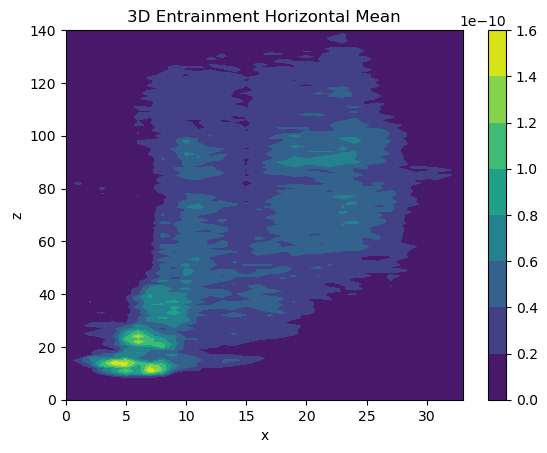

In [132]:
profile_array_e=np.load('profile_array_e.npy')

out=np.mean(profile_array_e,axis=(2,3))
plt.contourf(out)
plt.colorbar()
plt.title('3D Entrainment Horizontal Mean')
plt.xlabel('x');plt.ylabel('z')

Text(0, 0.5, 'z')

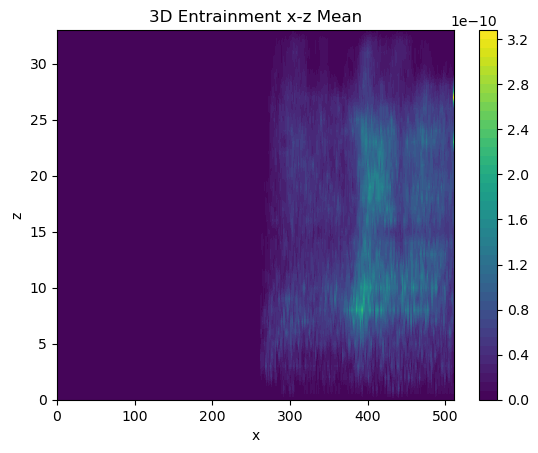

In [133]:
out=np.mean(profile_array_e,axis=(0,2))
# plt.plot(m,data['zh'])
plt.contourf(out,levels=50)
plt.title('3D Entrainment x-z Mean')
plt.colorbar()
plt.xlabel('x');plt.ylabel('z')

Text(0, 0.5, 'z (km)')

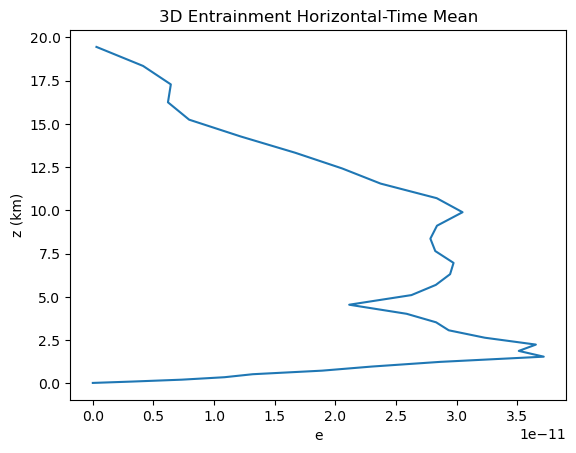

In [134]:
out=np.mean(profile_array_e,axis=(0,2,3))
# out=np.mean(profile_array_e*dy*dx,axis=(0,2,3))
plt.plot(out,data['zh'])
plt.title('3D Entrainment Horizontal-Time Mean')
plt.xlabel('e');plt.ylabel('z (km)')

In [ ]:
#RESIDENCE CODE

In [ ]:
#READING DATA BACK IN LATER

In [21]:
with h5py.File(dir+f'lagrangian_binary_threshold.h5', 'r') as f:
    # Load the dataset by its name
    A = f['A'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

In [361]:
#CALCULATING RESIDENCE TIMES
#############################

In [65]:
B=np.array([1,1,0,0,0,1,1,0,0,1,1])

# B=1-B #for detrainment, otherwise do comment out
print(f'binary {B}')
cat=np.concatenate(([0], B, [0]))
# print(f'cat {cat}')
diff=np.diff(cat)
print(f'diff {diff}')

binary [1 1 0 0 0 1 1 0 0 1 1]
diff [ 1  0 -1  0  0  1  0 -1  0  1  0 -1]


In [92]:
def residence_times(p,type):
    B = A[:,p]
    
    T=np.arange(len(B))
    
    if np.any(B)==True:
        if type=='e':
            B=B.copy()
        elif type=='d':
            B=1-B
    
        
        # Find the changes in the array
        # changes = np.diff(np.concatenate(([0], B, [0])))  # Add 0s to detect edges OLD
        changes = np.diff(np.concatenate(([0], B, [0])))  # Add 0s to detect edges OLD
            
        start_ind = np.where(changes == 1)[0]  # Start of sequences
        end_ind = np.where(changes == -1)[0]  # End of sequences
        
        # Calculate the lengths of sequences
        lengths = end_ind - start_ind

        sequences = [(start) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1] #only records en/detrainment time
        # sequences = [(start, *range(start + 1, end+1)) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1]
        lens=[(end-start) for start, end, length in zip(start_ind, end_ind, lengths) if length >= 1] #residence times

        #Remove the last one to get rid of entrainments that reach end of simulation
        sequences=sequences[:-1];lens=lens[:-1]

        
        ts=np.array(sequences.copy()) #only records en/detrainment time 
        # ts=np.array(tuple(item for seq in sequences for item in seq))

        if np.any(ts):
            zs=Z[ts,p]
            ys=Y[ts,p]
            xs=X[ts,p]
            return [lens,ts,zs,ys,xs]
        else:
            return []
    else:
        return []

p=42483; residence_times(p,type='d')

[[8, 1, 15, 3, 6, 10],
 array([ 0, 10, 12, 28, 32, 39]),
 array([ 8, 11, 14, 15, 14, 15]),
 array([69, 68, 68, 78, 82, 88]),
 array([347, 349, 350, 365, 368, 374])]

Text(0.5, 1.0, 'Testing')

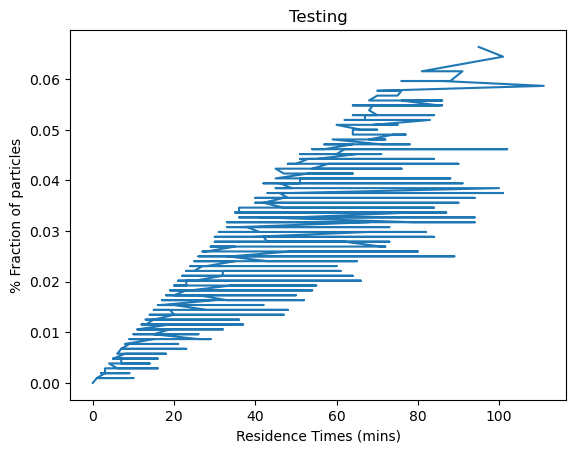

In [73]:
#TORRI 2015 TESTING TESTING TESTING
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
    out=residence_times(p,type='e')
    if np.any(out):
        xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        
        xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        xz_counter[out[2],out[4]]+=np.ones_like(out[0])


one=xz_array.flatten()
two=xz_counter.flatten()

#SORTING
sorted_indices = np.argsort(two)
sorted_two = two[sorted_indices]
sorted_one = one[sorted_indices]

plt.plot(sorted_one,sorted_two*100/(np.sum(xz_counter)))
plt.ylabel('% Fraction of particles');plt.xlabel('Residence Times (mins)')
plt.title("Testing")

In [86]:
#ENTRAINMENT/DETRAINMENT PROFILES
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
    out=residence_times(p,type='e')
    if np.any(out):
        xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        
        xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        xz_counter[out[2],out[4]]+=np.ones_like(out[0])


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]

#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

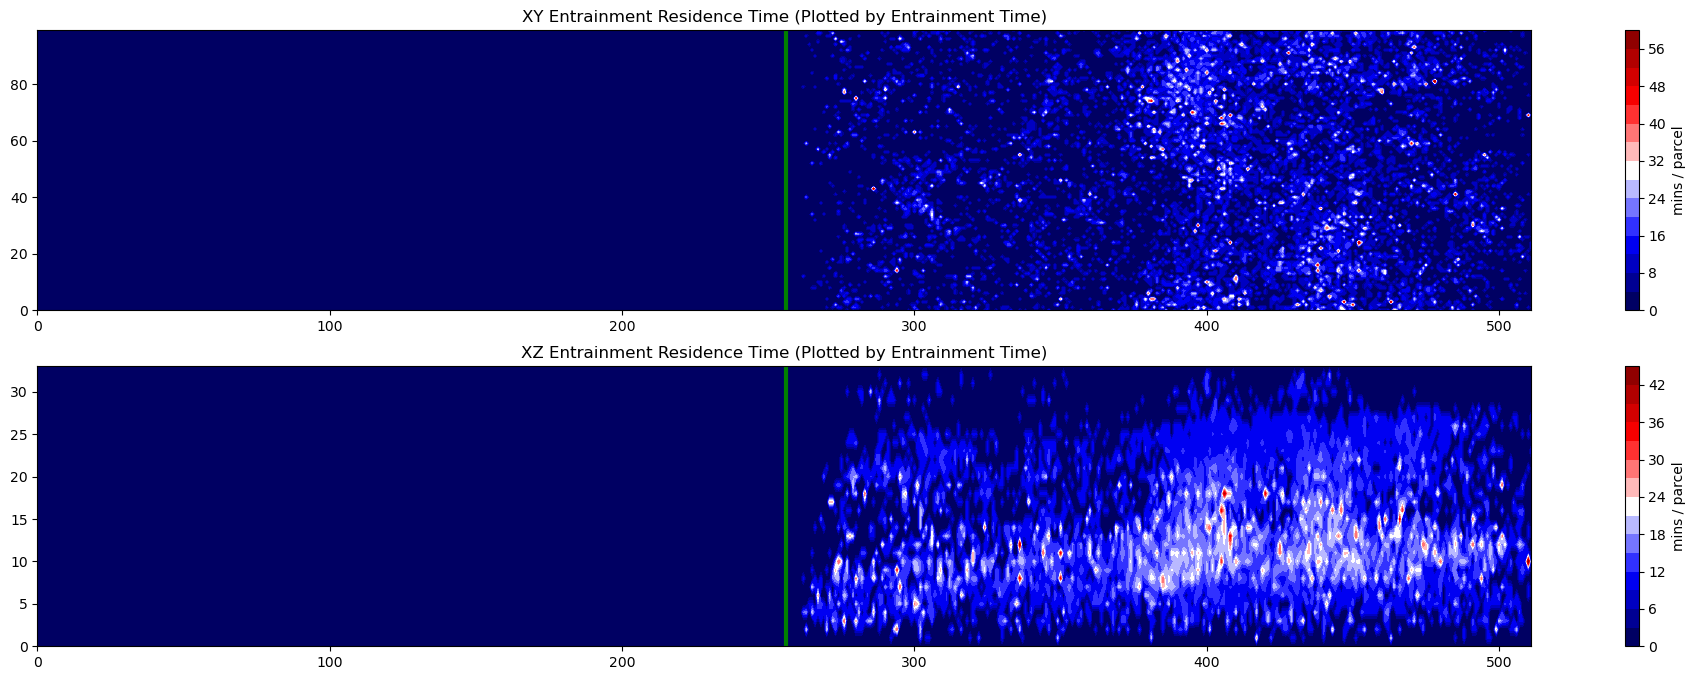

In [87]:
fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Entrainment Residence Time (Plotted by Entrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Entrainment Residence Time (Plotted by Entrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



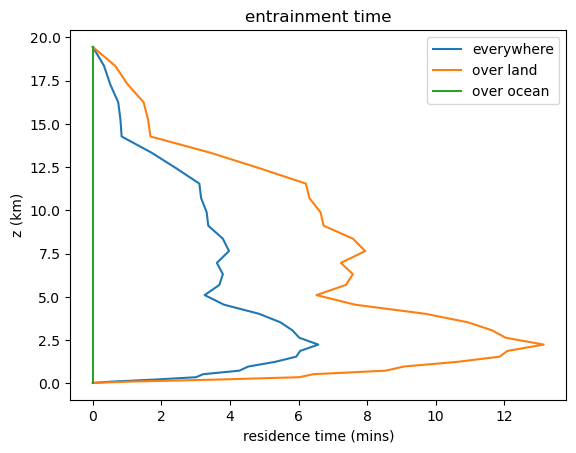

In [88]:
# currently i look for runs of being in cloudy updraft that are at least 5 minutes (1 timestep). i add the total length of that run at the location of initial entrainment/detrainment. then i average to get vertical profile. 

# For entrainment, particles should stay in a cloud for 30/60 minutes
# I’m very surprised by a) the extremely low values for entrainment time and b) the extremely high values for detainment times
# another thing: this is only cloudy updrafts, not clouds as well. is that 30/60 minutes true for the “cloud updrafts”?
# for detrainment then, there are some parcels that don’t interact with any “cloudy updrafts” for a very long time.
# also, if you look at the contour plot we do have higher values than the vertical profile 

plt.plot(np.mean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')
plt.ylabel('z (km)');plt.xlabel('residence time (mins)')


plt.plot(np.mean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')
plt.ylabel('z (km)');plt.xlabel('residence time (mins)')

plt.plot(np.mean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')
plt.ylabel('z (km)');plt.xlabel('residence time (mins)')

plt.title('entrainment time')
plt.legend()

In [89]:
Nx=len(data['xh']);Ny=len(data['yh']);Nz=len(data['zh'])
xy_array=np.zeros((Ny,Nx));xy_counter=np.zeros_like(xy_array)
xz_array=np.zeros((Nz,Nx));xz_counter=np.zeros_like(xz_array)

Np=125000-1
for p in np.arange(Np): 
    out=residence_times(p,type='d')
    if np.any(out):
        xy_array[out[3],out[4]]+=out[0] #add the (x,y) residence times 
        xy_counter[out[3],out[4]]+=np.ones_like(out[0])
        
        xz_array[out[2],out[4]]+=out[0] #add the (x,z) residence times 
        xz_counter[out[2],out[4]]+=np.ones_like(out[0])


#Divide by Counts
mask = xy_counter != 0
xy_array[mask]/=xy_counter[mask]
mask = xz_counter != 0
xz_array[mask]/=xz_counter[mask]


#Convert to Minutes
mins=((data['time'][1]-data['time'][0])/1e9/60).item()
xy_array*=mins
xz_array*=mins

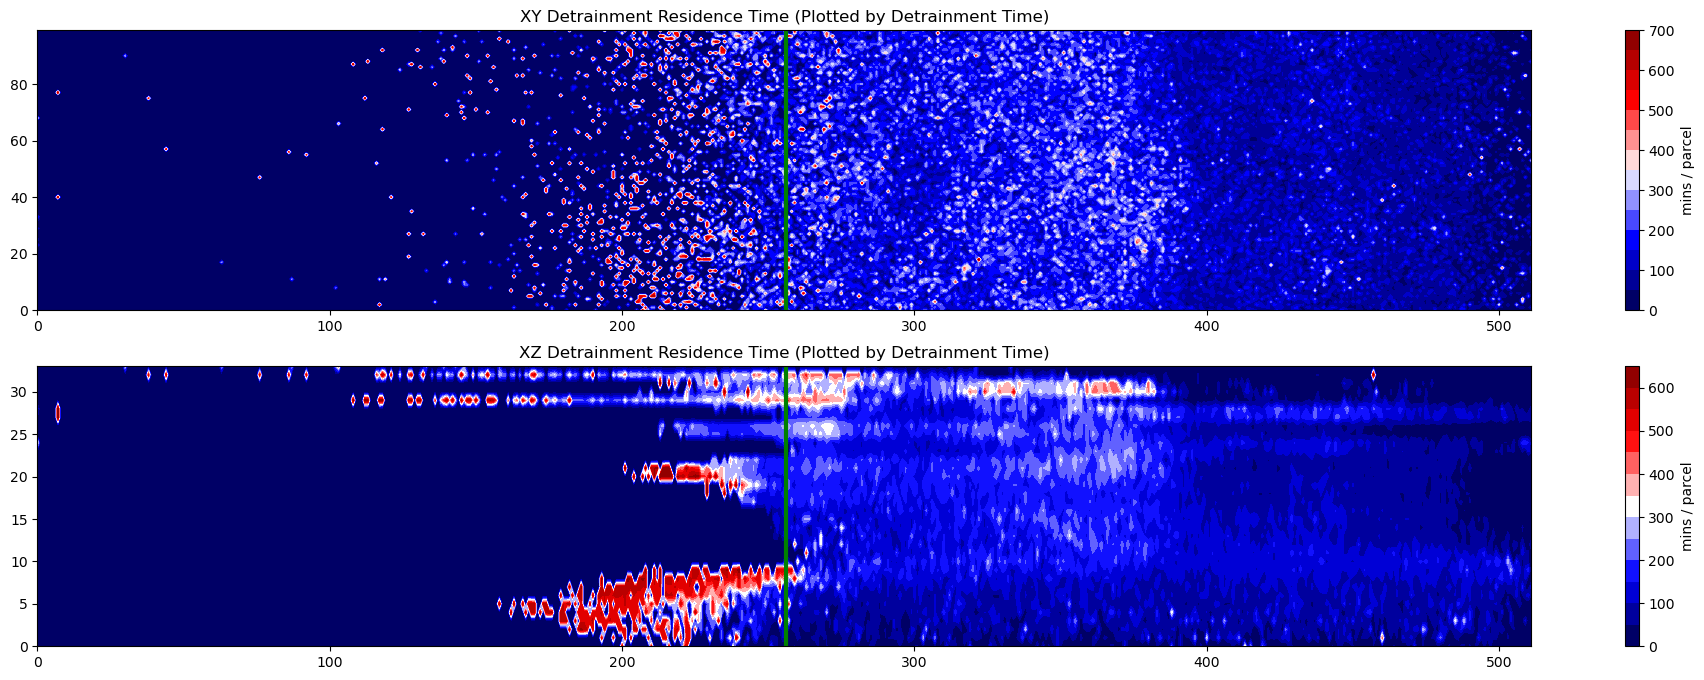

In [90]:
fig = plt.figure(figsize=(8*(512/34)/5, 8))
gs = gridspec.GridSpec(2, 1)  # 1 row, 2 columns
cmap='seismic'
levels1=15;levels2=15

# First subplot (xy_array contour)
ax1 = fig.add_subplot(gs[0, 0])  # First column
contour1 = ax1.contourf(xy_array,levels=levels1,cmap=cmap)
cbar1 = plt.colorbar(contour1, ax=ax1);cbar1.set_label("mins / parcel")
ax1.set_title("XY Detrainment Residence Time (Plotted by Detrainment Time)")

# Second subplot (xz_array contour)
ax2 = fig.add_subplot(gs[1, 0])  # Second column
contour2 = ax2.contourf(xz_array, levels=levels2, cmap=cmap)
cbar2 = plt.colorbar(contour2, ax=ax2);cbar2.set_label("mins / parcel")
ax2.set_title("XZ Detrainment Residence Time (Plotted by Detrainment Time)")


#COASTLINE
ax1.axvline(xy_array.shape[1]/2,color='green',linewidth=3)
ax2.axvline(xy_array.shape[1]/2,color='green',linewidth=3)

#THICKEN COLOR LINES

for edge in cbar1.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(10)
for edge in cbar2.ax.collections:  # Loop over individual elements in each list
    edge.set_linewidth(8)



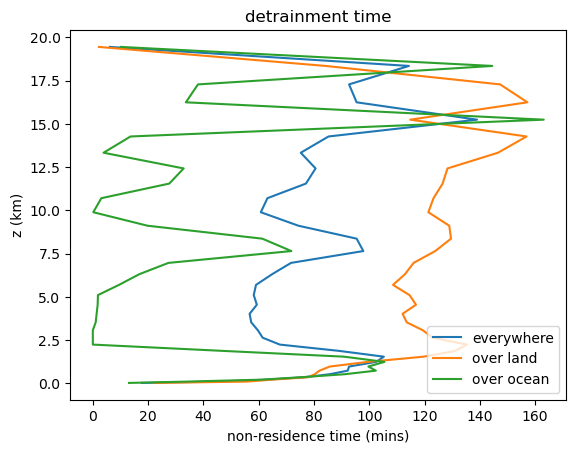

In [91]:
plt.plot(np.mean(xz_array[:,:],axis=(1)),data['zh'],label='everywhere')


plt.plot(np.mean(xz_array[:,int(512/2):512],axis=(1)),data['zh'],label='over land')


plt.plot(np.mean(xz_array[:,0:int(512/2)],axis=(1)),data['zh'],label='over ocean')


plt.title('detrainment time')
plt.ylabel('z (km)');plt.xlabel('non-residence time (mins)')
plt.legend()

In [ ]:
#IMPORTANT FOR PLOTTING

# xticks/yticks
# xticks = plt.gca().get_xticks()
# new_labels = [str(int(tick * 5)) for tick in xticks]
# plt.gca().set_xticklabels(new_labels);

# cbar-ticks
# cbar_ticks = cbar.get_ticks()  # Get the current ticks
# new_ticks = [str(int(tick * 5)) for tick in cbar_ticks]  # Modify ticks (multiply by 5 and convert to string)
# cbar.set_ticks(cbar_ticks)  # Set the original ticks again to avoid resetting
# cbar.set_ticklabels(new_ticks)


#imshow
# plt.yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)

In [ ]:
#MAKING 2D HISTOGRAM OF RESIDENCE TIME VS Z (COLOR: VARIABLE)

In [93]:
Nz=len(data['zh'])
profile=np.zeros((18,Nz)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        profile[lens,zs]+=np.ones_like(lens)
#         counter[lens,zs]+=np.ones_like(lens)

# #averaging by number of parcel
# mask=profile!=0
# profile[mask]/=counter[mask]

#NORMALIZATION
profile/=np.max(profile)

Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).
/tmp/ipykernel_2030145/107639488.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


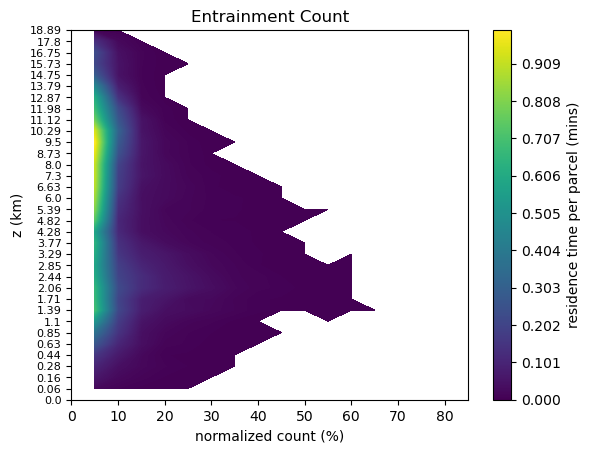

In [94]:
residence_profile=profile.copy() #save for comparing with TKE later


#Nan out zeros
cmap='viridis'
profile2=profile.copy()
profile2[profile2==0]=np.nan


#PLOTTING
# plt.imshow(profile.T);plt.gca().invert_yaxis()
plt.contourf(profile2.T,cmap=cmap,levels=1000)

cbar=plt.colorbar(label='residence time per parcel (mins)')
plt.ylabel('z (km)');plt.xlabel('normalized count (%)')
plt.title('Entrainment Count')

#FIXING TICKS

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);


In [95]:
with h5py.File(dir+f'lagrangian_binary_threshold.h5', 'r') as f:
    # Load the dataset by its name
    A = f['A'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

In [96]:
#Loading Some Data
w_data=data['w'].interp(zf=data['zh']).data

In [97]:
Nz=len(data['zh'])
profile=np.zeros((18,Nz)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        profile[lens,zs]+=w_data[ts,zs,ys,xs]
        counter[lens,zs]+=np.ones_like(lens)

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_2030145/2941328695.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


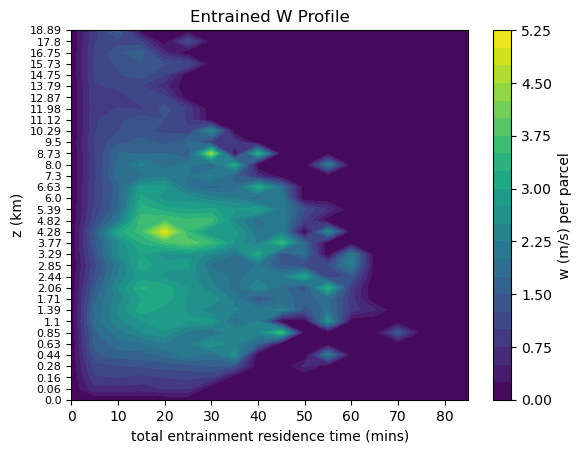

In [98]:
plt.contourf(profile.T,levels=20)
plt.colorbar(label='w (m/s) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrained W Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);


plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

In [106]:
with h5py.File(dir+'theta_e.h5', 'r') as f:
    # Load the dataset by its name
    theta_e_data = f['theta_e'][:]

In [100]:
Nz=len(data['zh'])
profile=np.zeros((18,Nz)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        profile[lens,zs]+=theta_e_data[ts,zs,ys,xs]
        counter[lens,zs]+=np.ones_like(lens)

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_2030145/2247899673.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


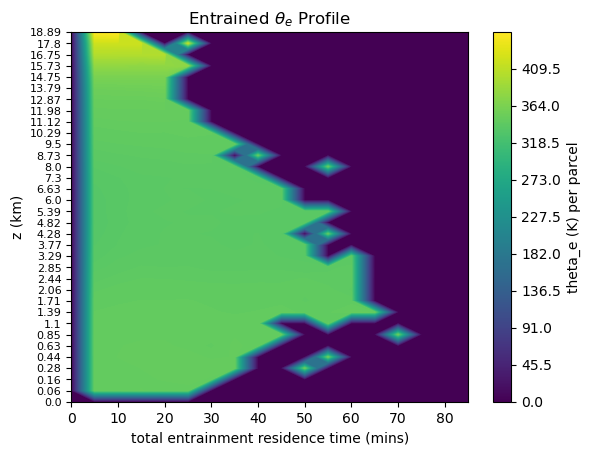

In [101]:
plt.contourf(profile.T,levels=1000)#,vmin=200)
plt.colorbar(label='theta_e (K) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title(r'Entrained $\theta_e$ Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);


In [102]:
#Loading Some Data
tke_data=data['tke'].interp(zf=data['zh']).data

In [103]:
Nz=len(data['zh'])
profile=np.zeros((18,Nz)); #residence time by Z levels
counter=np.zeros_like(profile)

Np=125000-1
for p in np.arange(Np):
    out=residence_times(p,type='e')
    if np.any(out)==True:
        lens=out[0]
        
        ts=out[1]
        zs=out[2]
        ys=out[3]
        xs=out[4]

        profile[lens,zs]+=tke_data[ts,zs,ys,xs]
        counter[lens,zs]+=np.ones_like(lens)

#averaging by number of parcel
mask=profile!=0
profile[mask]/=counter[mask]

/tmp/ipykernel_2030145/4078181305.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


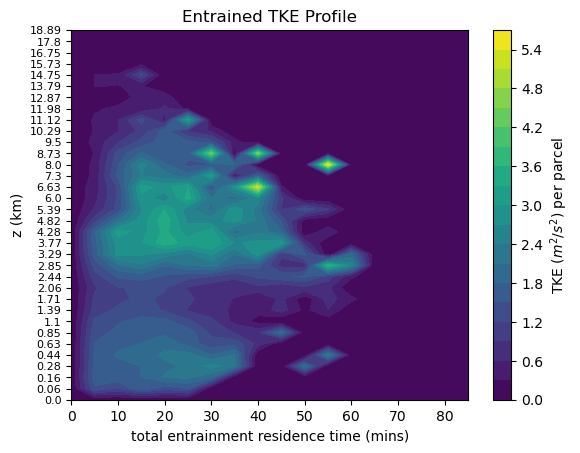

In [104]:
TKE_profile=profile.copy()


plt.contourf(profile.T,levels=20)
plt.colorbar(label=r'TKE ($m^2/s^2$) per parcel')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrained TKE Profile')

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);

/tmp/ipykernel_2030145/3499114643.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels);


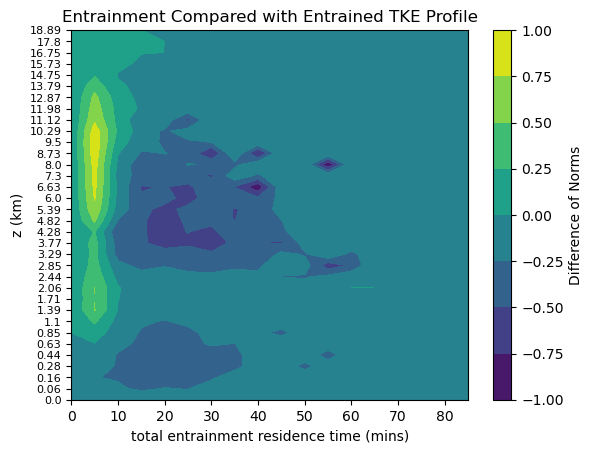

In [105]:
#TESTING TESTING TESTING


TKE_norm = (TKE_profile - np.min(TKE_profile)) / (np.max(TKE_profile) - np.min(TKE_profile))
residence_norm = (residence_profile - np.min(residence_profile)) / (np.max(residence_profile) - np.min(residence_profile))

compare_array = (1-TKE_norm) - (1-residence_norm)



plt.contourf(compare_array.T)
plt.colorbar(label='Difference of Norms')
plt.xlabel('total entrainment residence time (mins)');plt.ylabel('z (km)')
plt.title('Entrainment Compared with Entrained TKE Profile')

####

xticks = plt.gca().get_xticks()
new_labels = [str(int(tick * 5)) for tick in xticks]
plt.gca().set_xticklabels(new_labels);

plt.yticks(np.arange(Nz));
new_ytick_labels = np.round(data['zf'].values[:Nz], 2);
plt.gca().set_yticklabels(new_ytick_labels, fontsize=8, rotation=0);